In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
df = pd.read_csv('../data/cleaned/wednesday_cleaned.csv')
print(df.shape)
df.head()

(61001, 69)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Attack
0,443,87261,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,443,523,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,53,94304,1,1,56,338,56,56,56.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,53,207,2,2,84,246,42,42,42.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,123,69022032,2,2,96,96,48,48,48.0,0.0,...,22276.0,0.0,22276,22276,69000000.0,0.0,69000000,69000000,BENIGN,0


In [3]:
# check what columns we have for sanity check
print(df.columns)

Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_Header_Length',
       'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s',
       'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean',
       'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count',
       'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count'

In [4]:
# get numeric ones only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(len(numeric_cols))

# dont need label and attack
if 'Attack' in numeric_cols:
    numeric_cols.remove('Attack')
if 'Label' in numeric_cols:
    numeric_cols.remove('Label')
    
print(f'total: {len(numeric_cols)}')

68
total: 67


In [5]:
# compute correlation matrix
corr = df[numeric_cols].corr()
print(corr.shape)

(67, 67)


In [6]:
# look at sample using head 
corr.head()

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
Destination_Port,1.000000,-0.103267,-0.005904,-0.003534,0.024916,-0.003549,0.045483,-0.007507,0.051071,0.065646,...,-0.001157,-0.072081,-0.031829,-0.008801,-0.031826,-0.030614,-0.089913,-0.022116,-0.092503,-0.087092
Flow_Duration,-0.103267,1.000000,0.025705,0.022060,0.062456,0.018575,0.179564,-0.093084,0.015354,0.234234,...,0.015983,-0.292154,0.115342,0.089762,0.128126,0.098204,0.948873,0.188715,0.968868,0.924597
Total_Fwd_Packets,-0.005904,0.025705,1.000000,0.999149,0.354963,0.998919,0.024236,-0.006298,0.002163,0.017496,...,0.998543,-0.010738,0.011528,0.018991,0.016369,0.007729,0.005953,0.007099,0.006886,0.005206
Total_Backward_Packets,-0.003534,0.022060,0.999149,1.000000,0.352884,0.999509,0.023766,-0.003211,0.003741,0.017042,...,0.998808,-0.020166,-0.006893,0.005318,-0.003901,-0.007741,0.008431,-0.002531,0.007957,0.008669
Total_Length_of_Fwd_Packets,0.024916,0.062456,0.354963,0.352884,1.000000,0.341194,0.457159,0.053664,0.319920,0.400009,...,0.351657,-0.034493,0.035319,0.202354,0.076464,-0.009050,0.013424,0.014029,0.017374,0.012127


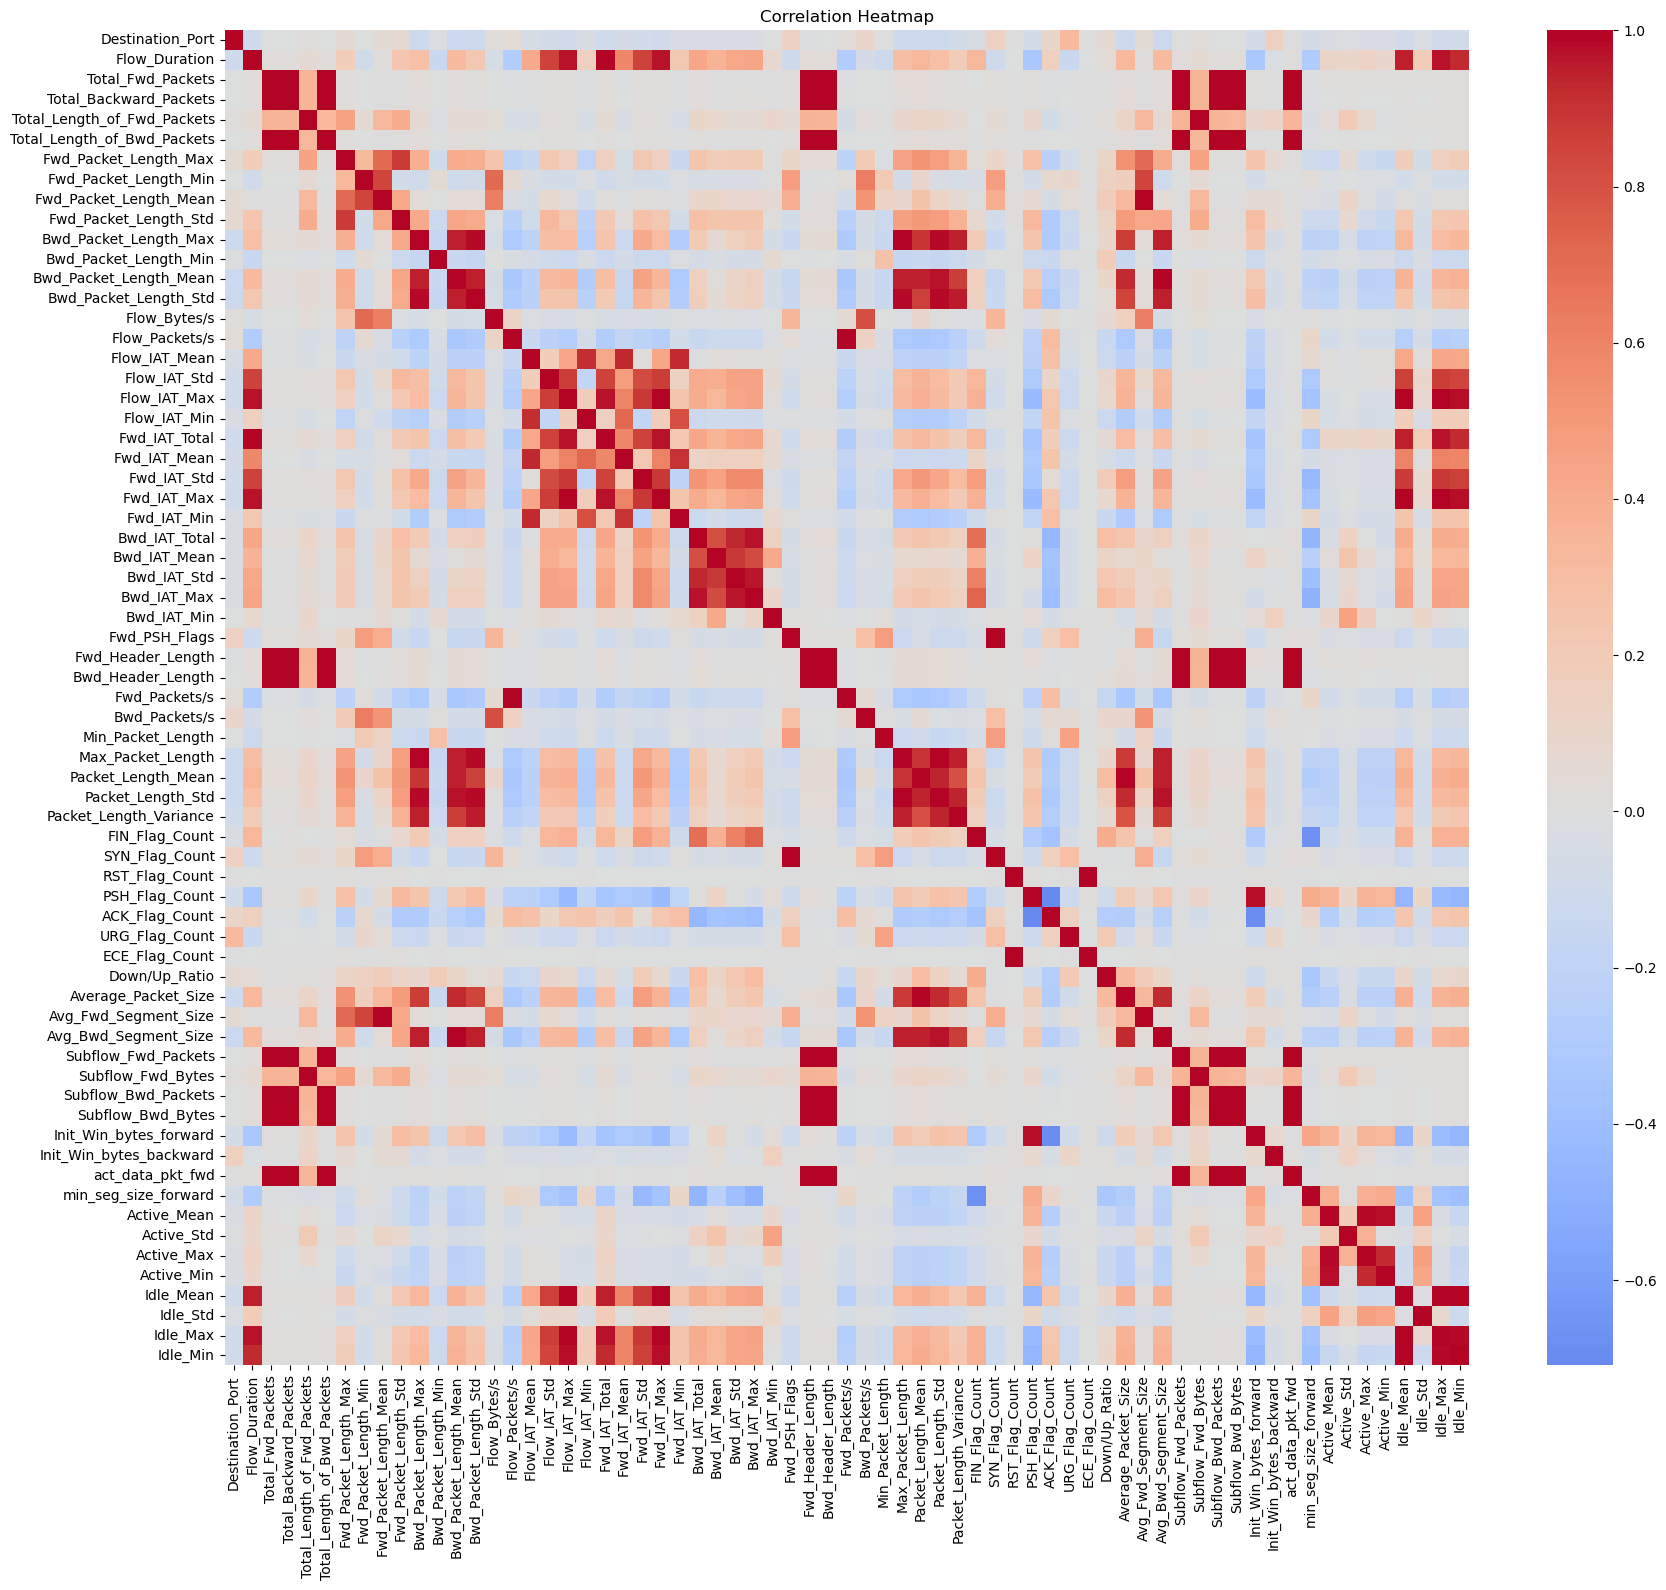

In [7]:
# make the heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../eda/figures/bivariate/correlation_heatmap_full.png', dpi=300)
plt.show()

In [8]:
# find pairs with high correlation
# gonna use 0.8 as the cutoff

pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.8:
            pairs.append([corr.columns[i], corr.columns[j], corr.iloc[i, j]])

print(f'found {len(pairs)} pairs')

found 131 pairs


In [9]:
# convert to df
df_pairs = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])

# sort it
df_pairs['abs'] = df_pairs['Correlation'].abs()
df_pairs = df_pairs.sort_values('abs', ascending=False)
df_pairs = df_pairs.drop('abs', axis=1)

print(df_pairs)

                       Feature 1               Feature 2  Correlation
23   Total_Length_of_Fwd_Packets       Subflow_Fwd_Bytes     1.000000
33        Fwd_Packet_Length_Mean    Avg_Fwd_Segment_Size     1.000000
12             Total_Fwd_Packets     Subflow_Fwd_Packets     1.000000
48        Bwd_Packet_Length_Mean    Avg_Bwd_Segment_Size     1.000000
93                 Fwd_PSH_Flags          SYN_Flag_Count     1.000000
..                           ...                     ...          ...
91                  Bwd_IAT_Mean             Bwd_IAT_Max     0.821205
55                  Flow_Bytes/s           Bwd_Packets/s     0.818692
87                 Bwd_IAT_Total            Bwd_IAT_Mean     0.815718
73                  Flow_IAT_Min             Fwd_IAT_Min     0.805732
109           Packet_Length_Mean  Packet_Length_Variance     0.800421

[131 rows x 3 columns]


In [10]:
# also check moderate ones (0.6-0.8)
moderate = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val >= 0.6 and val < 0.8:
            moderate.append([corr.columns[i], corr.columns[j], corr.iloc[i, j]])

print(f'moderate pairs: {len(moderate)}')

moderate pairs: 18


In [11]:
df_moderate = pd.DataFrame(moderate, columns=['Feature 1', 'Feature 2', 'Correlation'])
df_moderate['abs'] = df_moderate['Correlation'].abs()
df_moderate = df_moderate.sort_values('abs', ascending=False)
df_moderate = df_moderate.drop('abs', axis=1)

# just show top 20
print(df_moderate.head(20))

                 Feature 1               Feature 2  Correlation
14  Packet_Length_Variance     Average_Packet_Size     0.789661
13             Bwd_IAT_Max          FIN_Flag_Count     0.728896
7             Flow_IAT_Min            Fwd_IAT_Mean     0.721957
2    Fwd_Packet_Length_Min            Flow_Bytes/s     0.711502
16          PSH_Flag_Count          ACK_Flag_Count    -0.709238
0    Fwd_Packet_Length_Max  Fwd_Packet_Length_Mean     0.706605
1    Fwd_Packet_Length_Max    Avg_Fwd_Segment_Size     0.706605
11           Bwd_IAT_Total          FIN_Flag_Count     0.687396
17          ACK_Flag_Count  Init_Win_bytes_forward    -0.682698
15          FIN_Flag_Count    min_seg_size_forward    -0.669568
3    Fwd_Packet_Length_Min           Bwd_Packets/s     0.628759
4   Fwd_Packet_Length_Mean            Flow_Bytes/s     0.617944
5             Flow_Bytes/s    Avg_Fwd_Segment_Size     0.617944
12             Bwd_IAT_Std          FIN_Flag_Count     0.611653
8             Fwd_IAT_Mean             F

In [12]:
# get all the correlation values to see overall distribution
all_vals = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        all_vals.append(corr.iloc[i, j])

print(f'total: {len(all_vals)}')
print(f'mean: {np.mean(all_vals)}')
print(f'max: {np.max(all_vals)}')
print(f'min: {np.min(all_vals)}')

total: 2211
mean: 0.0820461687851181
max: 1.0
min: -0.7092376446970031


In [13]:
# count how many in different buckets
count_90 = 0
count_80 = 0
count_70 = 0
count_60 = 0

for c in all_vals:
    if abs(c) >= 0.9:
        count_90 += 1
    if abs(c) >= 0.8:
        count_80 += 1
    if abs(c) >= 0.7:
        count_70 += 1
    if abs(c) >= 0.6:
        count_60 += 1
        
print('corr >= 0.9:', count_90)
print('corr >= 0.8:', count_80)
print('corr >= 0.7:', count_70)
print('corr >= 0.6:', count_60)

corr >= 0.9: 99
corr >= 0.8: 131
corr >= 0.7: 138
corr >= 0.6: 149


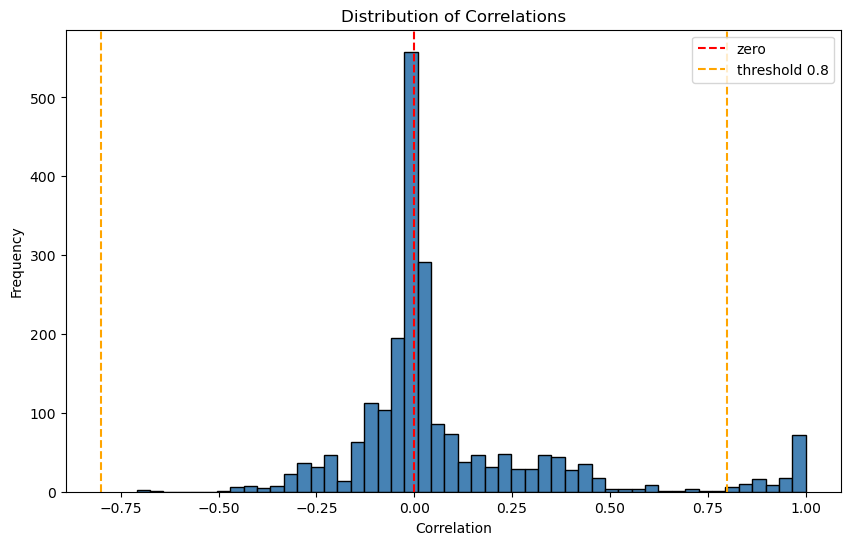

In [14]:
# plot histogram
plt.figure(figsize=(10, 6))
plt.hist(all_vals, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Correlations')
plt.axvline(x=0, color='red', linestyle='--', label='zero')
plt.axvline(x=0.8, color='orange', linestyle='--', label='threshold 0.8')
plt.axvline(x=-0.8, color='orange', linestyle='--')
plt.legend()
plt.savefig('../eda/figures/bivariate/correlation_distribution.png', dpi=300)
plt.show()

12/2/2025 - Umar

computed correlation matrix and made heatmap. found 131 pairs with correlation over 0.8 which is a lot. these are probably redundant and we should remove some before modeling. also made histogram showing most correlations are near zero but there are clusters of high ones.

next: probably need to pick which features to drop from the highly correlated pairs

### Done with Task

12/05/2025 - Moosa
Purpose: To Generate `pairplot()` using Seaborn for some selected features

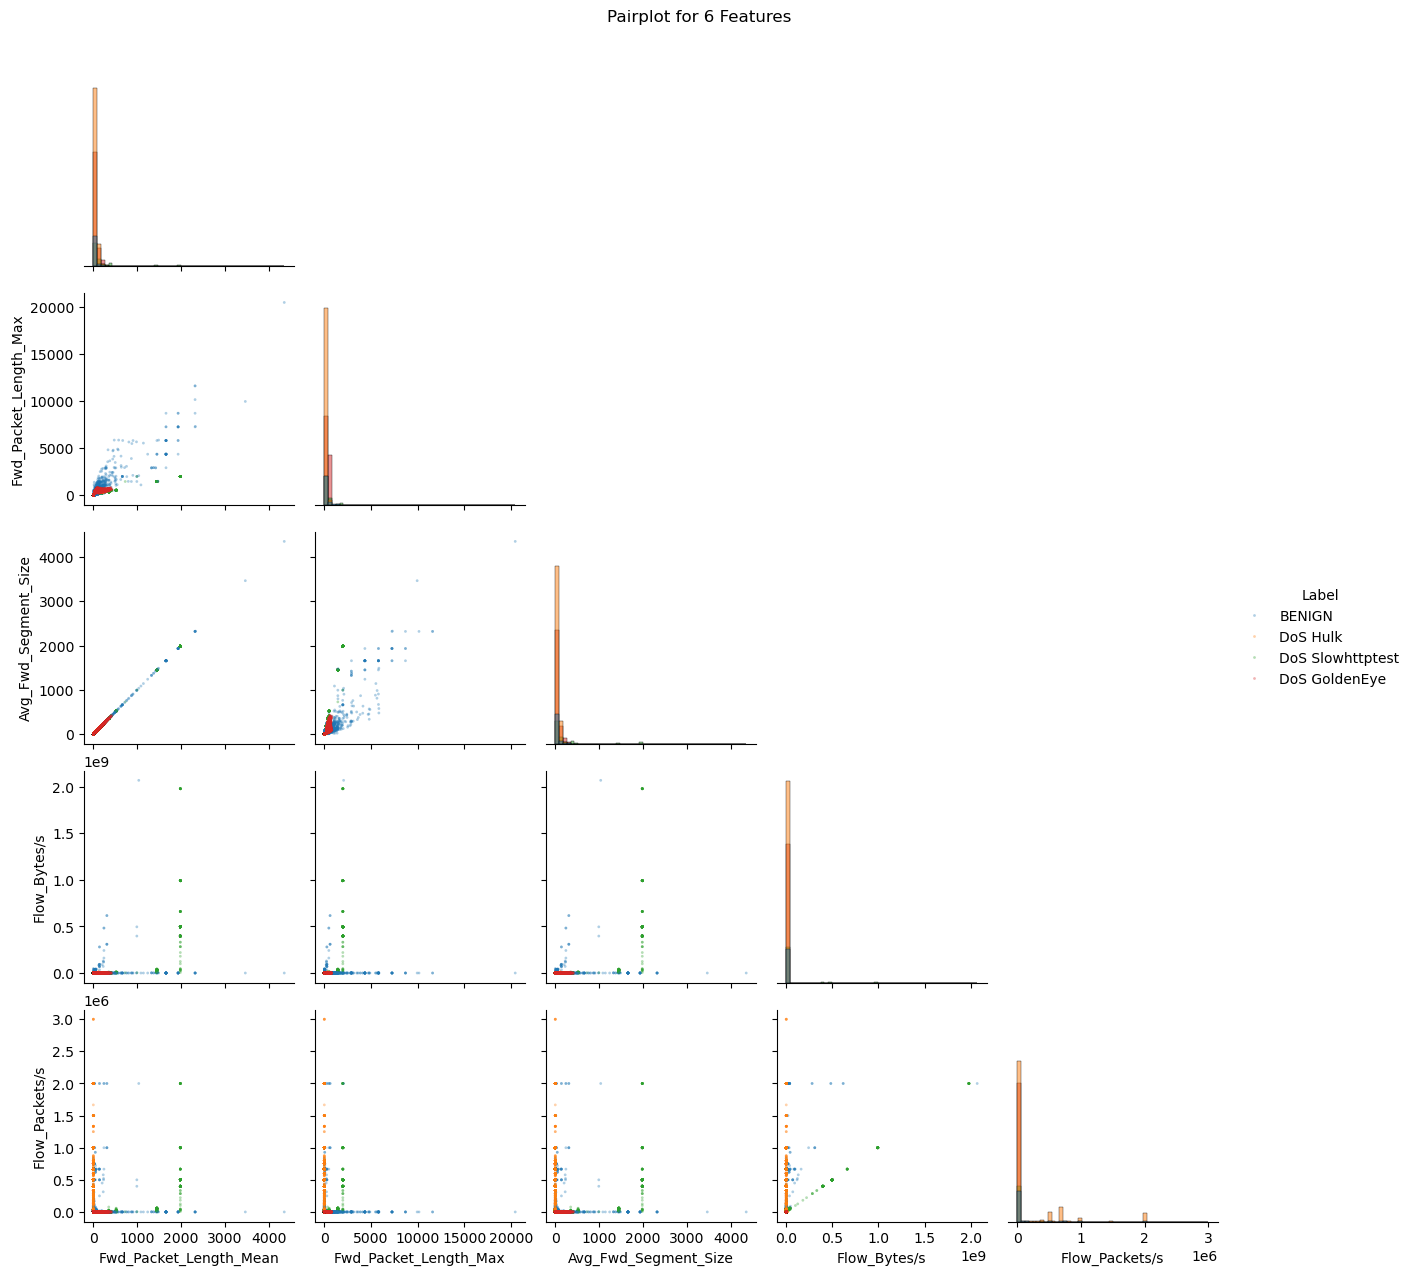

In [15]:
import seaborn as sns
 
import matplotlib.pyplot as plt
 
selected = [
 
    "Fwd_Packet_Length_Mean",
 
    "Fwd_Packet_Length_Max",
 
    "Avg_Fwd_Segment_Size",
 
    "Flow_Bytes/s",
 
    "Flow_Packets/s",
 
    "Label"
 
]
 
pairgrid = sns.pairplot(
 
    df[selected],
 
    hue="Label",
   
    kind = "scatter",
 
    diag_kind="hist",
 
    corner=True,
 
    plot_kws={"alpha": 0.35, "s": 8, "edgecolor": "none", "s": 4, "rasterized": True},
 
    diag_kws = {"bins": 50}
)
 
pairgrid.fig.suptitle("Pairplot for 6 Features", y=1.02)
 
pairgrid.savefig("../eda/figures/bivariate/pairplot6feat.png", dpi=180)
 
plt.show()